In [133]:
import numpy as np

In [134]:
# Slicing a numpy array
a = np.array([2, 4, 6, 8, 10])
b = np.array([1, 3])

In [135]:
a[b]

array([4, 8])

In [136]:
# Slicing a numpy array with condition
a = np.array([2, 4, 6, 8, 10, 12])
b = np.array([1, 3])

In [137]:
a[a>5]

array([ 6,  8, 10, 12])

In [138]:
a[a%3==0]

array([ 6, 12])

In [139]:
# Outer product
np.outer(np.array([1, 2, 3]), np.array([1, 2]))

array([[1, 2],
       [2, 4],
       [3, 6]])

In [140]:
# Data preparation
# XOR data
x_seeds = np.array([(0,0), (1,0), (0,1), (1,1)], dtype = np.float64)
y_seeds = np.array([0,1,1,0])

In [141]:
N = 1000
idxs = np.random.randint(0, 4, N)

In [142]:
X = x_seeds[idxs]
Y = y_seeds[idxs]

In [143]:
X += np.random.normal(scale = 0.25, size = X.shape)

In [144]:
# Model
class shallow_neural_network():
    def __init__(self, num_input_features, num_hiddens):
        self.num_input_features = num_input_features
        self.num_hiddens = num_hiddens
        
        self.W1 = np.random.normal(size = (num_hiddens, num_input_features))
        self.b1 = np.random.normal(size = num_hiddens)
        self.W2 = np.random.normal(size = num_hiddens)
        self.b2 = np.random.normal(size = 1)
        
    def sigmoid(self, z):
        return 1/(1 + np.exp(-z))
    
    def predict(self, x):
        z1 = np.matmul(self.W1, x) + self.b1
        a1 = np.tanh(z1)
        z2 = np.matmul(self.W2, a1) + self.b2
        a2 = self.sigmoid(z2)
        return a2, (z1, a1, z2, a2)

In [145]:
model = shallow_neural_network(2,3)

In [146]:
# Train (with element-wise operations)
def train(X, Y, model, lr = 0.1):
    dW1 = np.zeros_like(model.W1)
    db1 = np.zeros_like(model.b1)
    dW2 = np.zeros_like(model.W2)
    db2 = np.zeros_like(model.b2)
    m = len(X)
    cost = 0.0
    for x, y in zip(X, Y):
        a2, (z1, a1, z2, _) = model.predict(x)
        if y == 1:
            cost -= np.log(a2)
        else:
            cost -= np.log(1-a2)

        diff = a2-y
        # layer2
        # db2
        db2 += diff
        
        # db2 - todo: remove for-loops
        for i in range(model.num_hiddens):
            dW2[i] += a1[i]*diff
        # layer 1
        # db1 - todo: remove for-loops
        for i in range(model.num_hiddens):
            db1[i] += (1-a1[i]**2)*model.W2[i]*diff
        # db2 - todo: remove for-loops
        for i in range(model.num_hiddens):
            for j in range(model.num_input_features):
                dW1[i,j] += x[j]*(1-a1[i]**2)*model.W2[i]*diff
    
    cost /= m
    model.W1 -= lr * dW1/m
    model.b1 -= lr * db1/m
    model.W2 -= lr * dW2/m
    model.b2 -= lr * db2/m
    
    return cost

In [147]:
for epoch in range(100):
    cost = train (X, Y, model, 1.0)
    if epoch % 10 == 0:
        print(epoch, cost)

0 [0.70739263]
10 [0.59609524]
20 [0.49979242]
30 [0.40525076]
40 [0.33618253]
50 [0.2887]
60 [0.25635405]
70 [0.23394336]
80 [0.21800122]
90 [0.20634243]


In [123]:
# Test
model.predict((1,1))[0].item()

0.04757710737392423

In [124]:
model.predict((1,0))[0].item()

0.9067504671423873

In [125]:
model.predict((0,1))[0].item()

0.9766520093329734

In [126]:
model.predict((0,0))[0].item()

0.032707990715826814

In [127]:
# Data plotting
import matplotlib.pyplot as plt

idxs_1 = np.where(Y==1)
idxs_0 = np.where(Y==0)

In [128]:
X_0 = X[idxs_0]
Y_0 = Y[idxs_0]

In [129]:
X_1 = X[idxs_1]
Y_1 = Y[idxs_1]

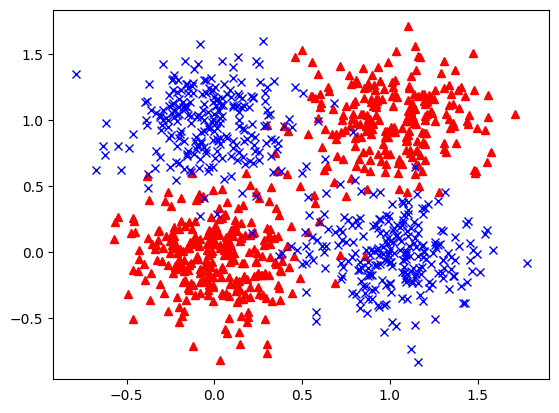

In [130]:
# plt.plot()
plt.plot(X_0[:,0], X_0[:,1], "r^")
plt.plot(X_1[:,0], X_1[:,1], "bx")